In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Risk matrix
A = np.array([
    [2, -1, 0, 0],
    [-1, 2, -1, 0],
    [0, -1, 2, -1],
    [0, 0, -1, 2]
])

symmetry = np.array_equal(A, A.T)

print("Is risk matrix symmetric?", symmetry)
banks = ["SBI", "ICICI", "HDFC", "Axis"]

Is risk matrix symmetric? True


In [8]:
from scipy.linalg import null_space
rank = np.linalg.matrix_rank(A)
det = np.linalg.det(A)
trace = np.trace(A)
null = null_space(A)

print("Rank:", rank)
print("Determinant:", det)
print("Trace:", trace)
print("Null space:\n", null)

Rank: 4
Determinant: 4.999999999999999
Trace: 8
Null space:
 []


In [9]:
# Shock vector
b = np.array([1, 2, 2, 1])

x_sol = np.linalg.solve(A, b)

print("Solution (Portfolio response):")
print(x_sol)

Solution (Portfolio response):
[3. 5. 5. 3.]


In [10]:
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

Eigenvalues:
 [3.61803399 2.61803399 0.38196601 1.38196601]

Eigenvectors:
 [[-0.37174803 -0.60150096 -0.37174803 -0.60150096]
 [ 0.60150096  0.37174803 -0.60150096 -0.37174803]
 [-0.60150096  0.37174803 -0.60150096  0.37174803]
 [ 0.37174803 -0.60150096 -0.37174803  0.60150096]]


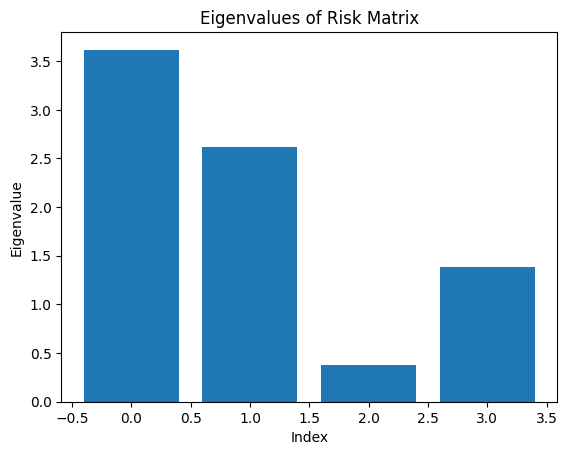

In [15]:
# Plot eigenvalues
plt.figure()
plt.bar(range(len(eigenvalues)), eigenvalues)
plt.title("Eigenvalues of Risk Matrix")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.show()

In [11]:
# Largest and smallest eigenvalues
largest = np.max(eigenvalues)
smallest = np.min(eigenvalues)

print("Largest Eigenvalue:", largest)
print("Smallest Eigenvalue:", smallest)

Largest Eigenvalue: 3.6180339887498913
Smallest Eigenvalue: 0.3819660112501053


In [18]:
# Get characteristic polynomial coefficients
coeffs = np.poly(A)

# polynomial evaluation at matrix A
I = np.eye(A.shape[0])
result = coeffs[0]*np.linalg.matrix_power(A,4) + \
         coeffs[1]*np.linalg.matrix_power(A,3) + \
         coeffs[2]*np.linalg.matrix_power(A,2) + \
         coeffs[3]*A + \
         coeffs[4]*I

print("Cayley-Hamilton Result (should be near zero matrix):")
print(result)

np.allclose(result, np.zeros_like(A))

Cayley-Hamilton Result (should be near zero matrix):
[[ 2.84217094e-14 -2.13162821e-14  7.10542736e-15 -2.66453526e-15]
 [-2.13162821e-14  2.84217094e-14 -2.13162821e-14  7.10542736e-15]
 [ 7.10542736e-15 -2.13162821e-14  2.84217094e-14 -2.13162821e-14]
 [-2.66453526e-15  7.10542736e-15 -2.13162821e-14  2.84217094e-14]]


True

Stock price responses to shock:
 [-8. -6. -4. -2.]


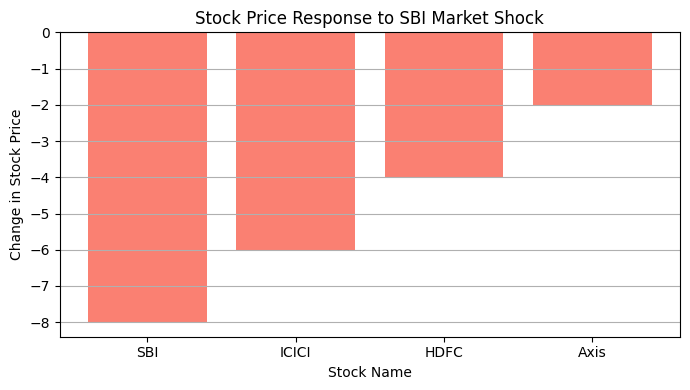

In [19]:
import matplotlib.pyplot as plt

shock_vector = np.array([-10, 0, 0, 0])

response = np.linalg.solve(A, shock_vector)

print("Stock price responses to shock:\n", response)

plt.figure(figsize=(7, 4))
plt.bar(banks, response, color='salmon')
plt.title('Stock Price Response to SBI Market Shock')
plt.ylabel('Change in Stock Price')
plt.xlabel('Stock Name')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

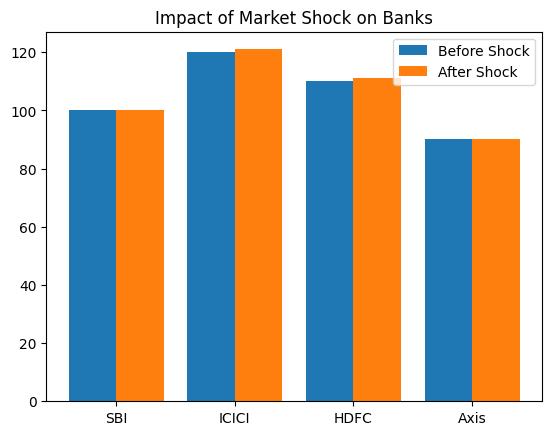

In [17]:
x_axis = np.arange(len(banks))

plt.figure()
plt.bar(x_axis - 0.2, initial, width=0.4, label='Before Shock')
plt.bar(x_axis + 0.2, response, width=0.4, label='After Shock')

plt.xticks(x_axis, banks)
plt.title("Impact of Market Shock on Banks")
plt.legend()
plt.show()

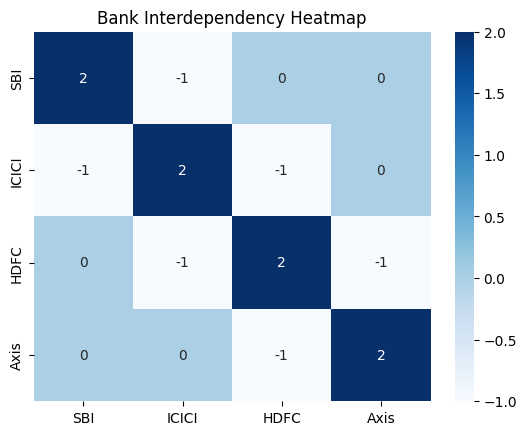

In [23]:
# Heatmap of risk matrix
plt.figure()
sns.heatmap(A, annot=True, cmap='Blues', xticklabels=banks, yticklabels=banks)
plt.title("Bank Interdependency Heatmap")
plt.show()